In [1]:
import xarray as xr
import matplotlib.pyplot as plt


In [8]:
import os
print(os.getcwd())

d:\my project\Climate Modelling\nootbokk\notebooks


In [9]:
import os

print(os.listdir("../"))
print(os.listdir("../../"))

['01_Xarray_Basics.ipynb', '03_Dataset_vs_DataArray.ipynb', '04_3D_Climate_Data.ipynb', 'CMIP_Introduction.ipynb', 'my_first_climate_dataset.nc', 'my_first_dataset.nc', 'my_first_dataset_v2.nc', 'notebooks']
['.git', 'data', 'nootbokk', 'notes', 'output', 'projects', 'README.md', 'script', 'website']


In [12]:
['.git', 'data', 'nootbokk', 'notes', 'output', 'projects', 'README.md', 'script', 'website']
for f in os.listdir("../../data/raw"):
    print(f)

era5_temp_jan2024.nc.nc


In [16]:
pip install netCDF4


   ---------------------------------------- 0.0/21.3 MB ? eta -:--:--
   ------- -------------------------------- 4.2/21.3 MB 20.9 MB/s eta 0:00:01
   ---------------- ----------------------- 8.7/21.3 MB 21.5 MB/s eta 0:00:01
   ----------------------- ---------------- 12.3/21.3 MB 19.8 MB/s eta 0:00:01
   ------------------------------- -------- 16.8/21.3 MB 20.3 MB/s eta 0:00:01
   ---------------------------------------  21.2/21.3 MB 21.0 MB/s eta 0:00:01
   ---------------------------------------- 21.3/21.3 MB 19.8 MB/s  0:00:01

   -------------------- ------------------- 1/2 [netCDF4]
   -------------------- ------------------- 1/2 [netCDF4]
   -------------------- ------------------- 1/2 [netCDF4]
   ---------------------------------------- 2/2 [netCDF4]



In [1]:
import xarray as xr

ds = xr.open_dataset("../../data/raw/era5_temp_jan2024.nc")

ds

<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-31T06:39 GRIB to CDM+CF via cfgrib-0.9.1...

In [2]:
ds.dims

FrozenMappingWarningOnValuesAccess({'valid_time': 1, 'latitude': 721, 'longitude': 1440})

In [3]:
ds.coords

Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      <U4 16B ...

In [4]:
ds.data_vars

Data variables:
    t2m      (valid_time, latitude, longitude) float32 4MB ...

In [5]:
list(ds.data_vars)

['t2m']

In [6]:
ds.t2m

<xarray.DataArray 't2m' (valid_time: 1, latitude: 721, longitude: 1440)> Size: 4MB
[1038240 values with dtype=float32]
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      <U4 16B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [7]:
#remove time dimession
temp = ds.t2m.isel(valid_time=0)
temp

<xarray.DataArray 't2m' (latitude: 721, longitude: 1440)> Size: 4MB
[1038240 values with dtype=float32]
Coordinates:
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2024-01-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      <U4 16B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

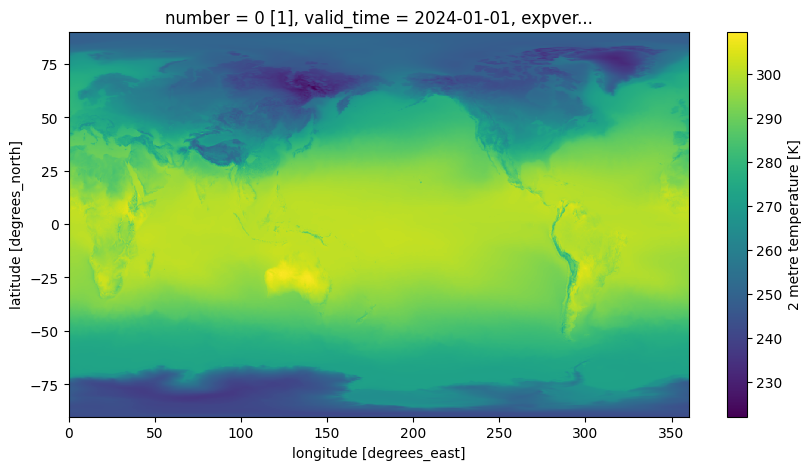

In [8]:
temp.plot(figsize=(10,5))

In [9]:
ds.t2m.attrs

{'GRIB_paramId': 167,
 'GRIB_dataType': 'an',
 'GRIB_numberOfPoints': 1038240,
 'GRIB_typeOfLevel': 'surface',
 'GRIB_stepUnits': 1,
 'GRIB_stepType': 'avgua',
 'GRIB_gridType': 'regular_ll',
 'GRIB_uvRelativeToGrid': 0,
 'GRIB_NV': 0,
 'GRIB_Nx': 1440,
 'GRIB_Ny': 721,
 'GRIB_cfName': 'unknown',
 'GRIB_cfVarName': 't2m',
 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid',
 'GRIB_iDirectionIncrementInDegrees': 0.25,
 'GRIB_iScansNegatively': 0,
 'GRIB_jDirectionIncrementInDegrees': 0.25,
 'GRIB_jPointsAreConsecutive': 0,
 'GRIB_jScansPositively': 0,
 'GRIB_latitudeOfFirstGridPointInDegrees': 90.0,
 'GRIB_latitudeOfLastGridPointInDegrees': -90.0,
 'GRIB_longitudeOfFirstGridPointInDegrees': 0.0,
 'GRIB_longitudeOfLastGridPointInDegrees': 359.75,
 'GRIB_missingValue': 3.4028234663852886e+38,
 'GRIB_name': '2 metre temperature',
 'GRIB_shortName': '2t',
 'GRIB_totalNumber': 0,
 'GRIB_units': 'K',
 'long_name': '2 metre temperature',
 'units': 'K',
 'standard_name': 'unknown',
 'G

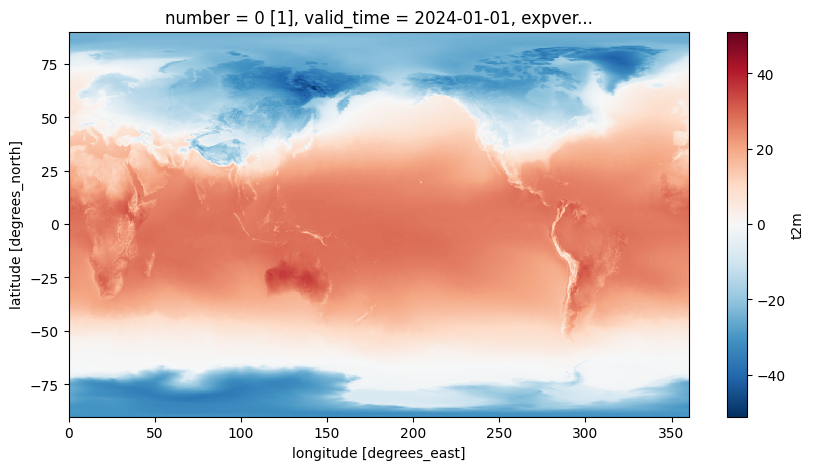

In [12]:
temp_c = temp-273.15

temp_c.plot(figsize=(10,5))

In [13]:
ds.dims
ds.coords
ds.t2m.attrs

{'GRIB_paramId': 167,
 'GRIB_dataType': 'an',
 'GRIB_numberOfPoints': 1038240,
 'GRIB_typeOfLevel': 'surface',
 'GRIB_stepUnits': 1,
 'GRIB_stepType': 'avgua',
 'GRIB_gridType': 'regular_ll',
 'GRIB_uvRelativeToGrid': 0,
 'GRIB_NV': 0,
 'GRIB_Nx': 1440,
 'GRIB_Ny': 721,
 'GRIB_cfName': 'unknown',
 'GRIB_cfVarName': 't2m',
 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid',
 'GRIB_iDirectionIncrementInDegrees': 0.25,
 'GRIB_iScansNegatively': 0,
 'GRIB_jDirectionIncrementInDegrees': 0.25,
 'GRIB_jPointsAreConsecutive': 0,
 'GRIB_jScansPositively': 0,
 'GRIB_latitudeOfFirstGridPointInDegrees': 90.0,
 'GRIB_latitudeOfLastGridPointInDegrees': -90.0,
 'GRIB_longitudeOfFirstGridPointInDegrees': 0.0,
 'GRIB_longitudeOfLastGridPointInDegrees': 359.75,
 'GRIB_missingValue': 3.4028234663852886e+38,
 'GRIB_name': '2 metre temperature',
 'GRIB_shortName': '2t',
 'GRIB_totalNumber': 0,
 'GRIB_units': 'K',
 'long_name': '2 metre temperature',
 'units': 'K',
 'standard_name': 'unknown',
 'G

In [16]:
import os
file_path = r"D:\my project\Climate Modelling\data\raw\era5_temp_jan2024.nc"
print(os.path.exists(file_path))

True


In [18]:
import os

print(os.listdir(r"D:\my project\Climate Modelling\data\raw"))

['era5_temp_jan2024.nc']


In [20]:
import os

file_path = r"D:\my project\Climate Modelling\data\raw\era5_temp_jan2024.nc"

print(os.path.isfile(file_path))

True


In [21]:
import xarray as xr
file_path  = r"D:\my project\Climate Modelling\data\raw\era5_temp_jan2024.nc"
ds = xr.open_dataset(file_path)
ds

<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-31T06:39 GRIB to CDM+CF via cfgrib-0.9.1...

In [22]:
ds.dims

FrozenMappingWarningOnValuesAccess({'valid_time': 1, 'latitude': 721, 'longitude': 1440})

In [23]:
ds.coords

Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      <U4 16B ...

In [24]:
ds.data_vars

Data variables:
    t2m      (valid_time, latitude, longitude) float32 4MB ...

In [25]:
ds.t2m

<xarray.DataArray 't2m' (valid_time: 1, latitude: 721, longitude: 1440)> Size: 4MB
[1038240 values with dtype=float32]
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      <U4 16B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [26]:
ds.t2m.shape

(1, 721, 1440)

In [27]:
temp_c = ds.t2m - 273.15

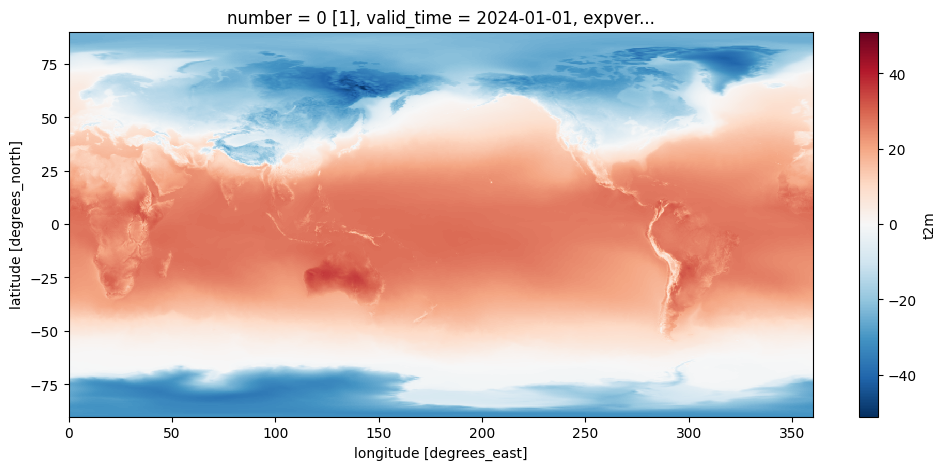

In [28]:
temp_c.isel(valid_time=0).plot(figsize=(12,5))

In [29]:
ds.latitude
ds.longitude

<xarray.DataArray 'longitude' (longitude: 1440)> Size: 12kB
array([0.0000e+00, 2.5000e-01, 5.0000e-01, ..., 3.5925e+02, 3.5950e+02,
       3.5975e+02])
Coordinates:
    number     int64 8B ...
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver     <U4 16B ...
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude

In [31]:
ds.t2m.shape
ds.latitude
ds.longitude

<xarray.DataArray 'longitude' (longitude: 1440)> Size: 12kB
array([0.0000e+00, 2.5000e-01, 5.0000e-01, ..., 3.5925e+02, 3.5950e+02,
       3.5975e+02])
Coordinates:
    number     int64 8B ...
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver     <U4 16B ...
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude

In [32]:
ds.latitude
ds.t2m.shape

(1, 721, 1440)

In [34]:
ds.latitude

<xarray.DataArray 'latitude' (latitude: 721)> Size: 6kB
array([ 90.  ,  89.75,  89.5 , ..., -89.5 , -89.75, -90.  ])
Coordinates:
    number    int64 8B ...
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    expver    <U4 16B ...
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing

In [36]:
india = ds.t2m.sel(
    latitude = slice(40,5),
    longitude = slice(65,100)

)
india

<xarray.DataArray 't2m' (valid_time: 1, latitude: 141, longitude: 141)> Size: 80kB
array([[[278.81525, 279.1922 , ..., 266.3211 , 266.1336 ],
        [279.38556, 279.79376, ..., 266.29572, 266.27423],
        ...,
        [301.075  , 301.06915, ..., 300.8426 , 300.64728],
        [301.08478, 301.08282, ..., 300.71564, 300.61603]]], dtype=float32)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01
  * latitude    (latitude) float64 1kB 40.0 39.75 39.5 39.25 ... 5.5 5.25 5.0
  * longitude   (longitude) float64 1kB 65.0 65.25 65.5 ... 99.5 99.75 100.0
    expver      <U4 16B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [37]:
india.shape

(1, 141, 141)

In [39]:
india_c  = india - 273.15

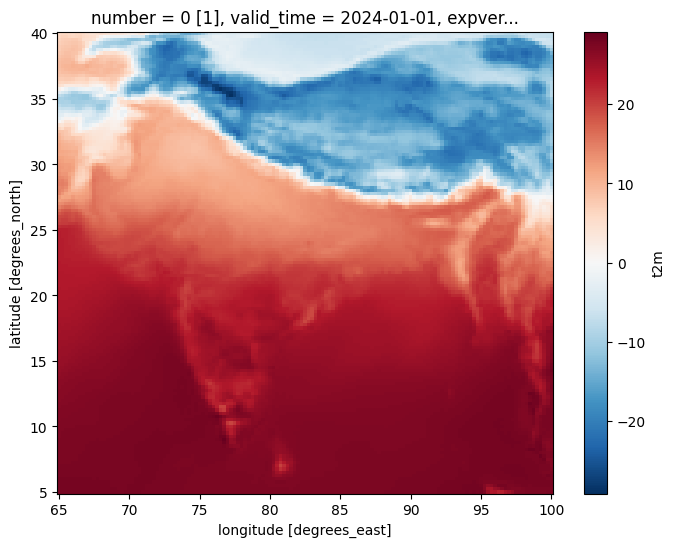

In [40]:
india_c.isel(valid_time = 0).plot(figsize=(8,6))

In [41]:
india_c.mean()

<xarray.DataArray 't2m' ()> Size: 8B
array(12.33854103)
Coordinates:
    number   int64 8B ...
    expver   <U4 16B ...

<xarray.DataArray 't2m' (valid_time: 1)> Size: 4B
array([8.370412], dtype=float32)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01
    expver      <U4 16B ...

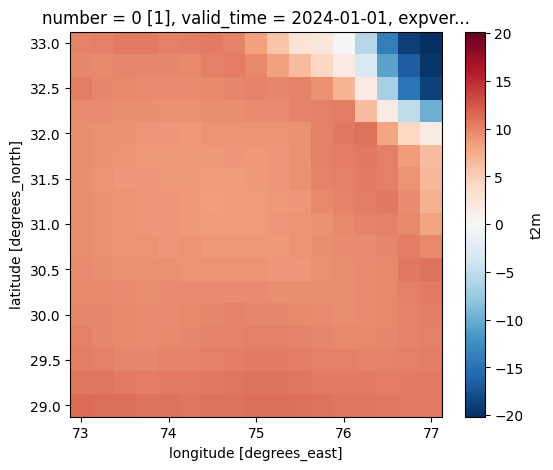

In [42]:
punjab = ds.t2m.sel(
    latitude = slice(33,29),
    longitude= slice(73,77)

)
punjab_c = punjab-273.15
punjab_c.shape
punjab_c.isel(valid_time =0).plot(figsize=(6,5))
punjab_c.mean()
punjab_c.mean(dim=["latitude","longitude"])


In [43]:
import xarray as xr
file_path  = r"D:\my project\Climate Modelling\data\raw\era5_t2m_2024.nc"
ds = xr.open_dataset(file_path)
ds

<xarray.Dataset> Size: 50MB
Dimensions:     (valid_time: 12, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 96B 2024-01-01 ... 2024-12-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 192B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 50MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-07T18:51 GRIB to CDM+CF via cfgrib-0.9.1...

In [44]:
ds.dims

FrozenMappingWarningOnValuesAccess({'valid_time': 12, 'latitude': 721, 'longitude': 1440})

In [45]:
ds.t2m.shape
ds.data_vars

Data variables:
    t2m      (valid_time, latitude, longitude) float32 50MB ...

In [46]:
ds.valid_time

<xarray.DataArray 'valid_time' (valid_time: 12)> Size: 96B
array(['2024-01-01T00:00:00.000000000', '2024-02-01T00:00:00.000000000',
       '2024-03-01T00:00:00.000000000', '2024-04-01T00:00:00.000000000',
       '2024-05-01T00:00:00.000000000', '2024-06-01T00:00:00.000000000',
       '2024-07-01T00:00:00.000000000', '2024-08-01T00:00:00.000000000',
       '2024-09-01T00:00:00.000000000', '2024-10-01T00:00:00.000000000',
       '2024-11-01T00:00:00.000000000', '2024-12-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 96B 2024-01-01 ... 2024-12-01
    expver      (valid_time) <U4 192B ...
Attributes:
    long_name:      time
    standard_name:  time

In [51]:
punjab = ds.t2m.sel(
    latitude=slice(33, 29),
    longitude=slice(73, 77)
)

punjab_c = punjab - 273.15

punjab_ts = punjab_c.mean(
    dim=["latitude", "longitude"]
)

punjab_ts

<xarray.DataArray 't2m' (valid_time: 12)> Size: 48B
array([ 8.370412, 13.392543, 18.917177, 24.363565, 31.086256, 32.66093 ,
       30.914825, 28.733044, 28.225166, 25.06279 , 18.519535, 11.36985 ],
      dtype=float32)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 96B 2024-01-01 ... 2024-12-01
    expver      (valid_time) <U4 192B ...

(12, 721, 1440)

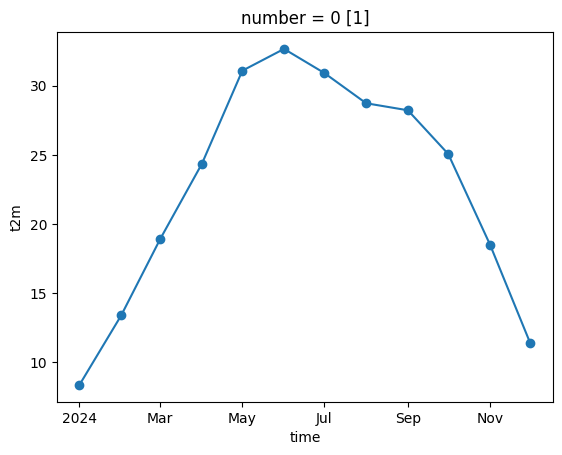

In [55]:
punjab_ts.plot(marker="o")
ds
ds.t2m.shape

In [56]:
ds

<xarray.Dataset> Size: 50MB
Dimensions:     (valid_time: 12, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 96B 2024-01-01 ... 2024-12-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 192B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 50MB 249.4 ... 244.5
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-07T18:51 GRIB to CDM+CF via cfgrib-0.9.1...

In [58]:
punjab = ds.t2m.sel(
    latitude =slice(33,29),
    longitude = slice(73,77)
)


In [59]:
punjab_ts = punjab_c.mean(
    dim = ["latitude","longitude"]
)
punjab_ts

<xarray.DataArray 't2m' (valid_time: 12)> Size: 48B
array([ 8.370412, 13.392543, 18.917177, 24.363565, 31.086256, 32.66093 ,
       30.914825, 28.733044, 28.225166, 25.06279 , 18.519535, 11.36985 ],
      dtype=float32)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 96B 2024-01-01 ... 2024-12-01
    expver      (valid_time) <U4 192B ...

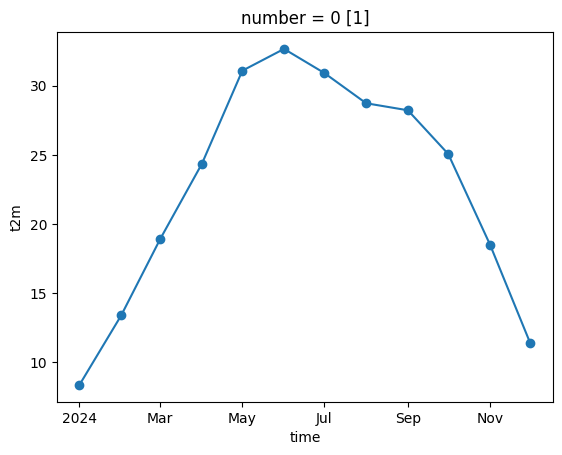

In [61]:
punjab_ts.plot(marker="o")

In [62]:
punjab_ts.values

array([ 8.370412, 13.392543, 18.917177, 24.363565, 31.086256, 32.66093 ,
       30.914825, 28.733044, 28.225166, 25.06279 , 18.519535, 11.36985 ],
      dtype=float32)

In [63]:
punjab_ts.valid_time.values

array(['2024-01-01T00:00:00.000000000', '2024-02-01T00:00:00.000000000',
       '2024-03-01T00:00:00.000000000', '2024-04-01T00:00:00.000000000',
       '2024-05-01T00:00:00.000000000', '2024-06-01T00:00:00.000000000',
       '2024-07-01T00:00:00.000000000', '2024-08-01T00:00:00.000000000',
       '2024-09-01T00:00:00.000000000', '2024-10-01T00:00:00.000000000',
       '2024-11-01T00:00:00.000000000', '2024-12-01T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [65]:
punjab_ts.mean()

<xarray.DataArray 't2m' ()> Size: 8B
array(22.63467407)
Coordinates:
    number   int64 8B ...

In [67]:
punjab_ts.shape

(12,)

In [68]:
punjab_ts.values

array([ 8.370412, 13.392543, 18.917177, 24.363565, 31.086256, 32.66093 ,
       30.914825, 28.733044, 28.225166, 25.06279 , 18.519535, 11.36985 ],
      dtype=float32)

In [73]:
print("Warmest:",float(punjab_ts.max()))
print("Coldest:",float(punjab_ts.min()))


Warmest: 32.66093063354492
Coldest: 8.37041187286377


In [75]:
punjab_ts.idxmax().values


numpy.datetime64('2024-06-01T00:00:00.000000000')

In [76]:
punjab_ts.idxmin().values

numpy.datetime64('2024-01-01T00:00:00.000000000')